In [1]:
# ============================================================
# 1. Imports
# ============================================================

import os
import json
import math
import time
import shutil
import hashlib
import platform
import datetime as dt
from pathlib import Path
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import sparse

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    brier_score_loss,
    roc_curve,
    precision_recall_curve,
)
from sklearn.exceptions import ConvergenceWarning

import joblib
import warnings

warnings.filterwarnings("ignore", category=ConvergenceWarning)

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 120)

print("Python:", platform.python_version())
print("Platform:", platform.platform())


Python: 3.12.13
Platform: Linux-6.12.90+-x86_64-with-glibc2.35


In [2]:
# ============================================================
# 2. Central configuration
# ============================================================

CONFIG = {
    # Experiment identity
    "project_name": "extremism_text_classification",
    "technique_name": "LIN-SVM_TF-IDF",
    "model_family": "calibrated_linear_svm",
    "feature_family": "tfidf_word",
    "dataset_version": "extremism_dataset_clean_v1",
    "split_version": "split_v1",
    "random_seed": 30,

    # Paths
    # Leave these as None to auto-discover the files under /kaggle/input or /kaggle/working.
    # If auto-discovery fails, paste exact paths from Kaggle's file browser.
    "processed_dataset_path": None,
    "split_assignments_path": None,
    "dataset_manifest_path": None,

    # Required columns from 00_create_dataset_and_splits.ipynb
    "id_col": "row_id",
    "text_col": "text",
    "label_col": "label",
    "split_col": "split",
    "positive_label": 1,

    # Output
    "output_root": "/kaggle/working/experiments",
    "overwrite_output_dir": True,

    # Ablation / tuning
    # This grid is validation-only. It is moderately extensive but still realistic for Kaggle.
    # Total configs: 3 * 2 * 2 * 1 * 1 * 4 * 2 = 96.
    "ablation_grid": {
        "max_features": [10000, 20000, 50000],
        "ngram_range": [[1, 1], [1, 2]],
        "min_df": [1, 2],
        "max_df": [0.95],
        "sublinear_tf": [True],
        "C": [0.1, 1.0, 3.0, 10.0],
        "class_weight": [None, "balanced"],
    },

    # Linear SVM settings
    "linear_svm": {
        "max_iter": 5000,
        "tol": 1e-4,
        "random_state": 30,
    },

    # Calibration settings
    # LinearSVC does not natively provide probabilities, so we calibrate using train-only CV.
    # This allows PR-AUC, ROC-AUC, Brier score, calibration plots, and validation threshold tuning.
    "calibration": {
        "method": "sigmoid",
        "cv": 3,
    },

    # Thresholding
    # Recommended default: maximize validation positive-class F1.
    "threshold_strategy": "maximize_val_f1",
    "threshold_grid": {
        "start": 0.01,
        "stop": 0.99,
        "num": 99,
    },

    # Explainability
    "explainability": {
        "top_n_global": 100,
        "top_k_local_features": 15,
        "max_local_examples_total": 120,
        "include_text_preview": False,
        "text_preview_chars": 240,
    },

    # Error analysis
    "error_analysis": {
        "examples_per_bucket": 25,
        "near_threshold_margin": 0.05,
        "include_text_preview": False,
        "text_preview_chars": 240,
    },
}

TECHNIQUE_NAME = CONFIG["technique_name"]
OUTPUT_DIR = Path(CONFIG["output_root"]) / TECHNIQUE_NAME

print("Technique:", TECHNIQUE_NAME)
print("Output directory:", OUTPUT_DIR)


Technique: LIN-SVM_TF-IDF
Output directory: /kaggle/working/experiments/LIN-SVM_TF-IDF


In [3]:
# ============================================================
# 3. Reproducibility and helper functions
# ============================================================

def set_global_seed(seed: int) -> None:
    import random
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

def make_json_safe(obj):
    """Convert numpy/scipy/path objects into JSON-serializable Python objects."""
    if isinstance(obj, dict):
        return {str(k): make_json_safe(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [make_json_safe(v) for v in obj]
    if isinstance(obj, Path):
        return str(obj)
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        if math.isnan(float(obj)):
            return None
        return float(obj)
    if isinstance(obj, (np.ndarray,)):
        return obj.tolist()
    try:
        if pd.isna(obj) and not isinstance(obj, (list, tuple, dict, np.ndarray)):
            return None
    except Exception:
        pass
    return obj

def save_json(obj, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w") as f:
        json.dump(make_json_safe(obj), f, indent=2)

def sha256_file(path: Path, n_chars: int = 16) -> str:
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()[:n_chars]

def sha256_text(text: str, n_chars: int = 16) -> str:
    return hashlib.sha256(str(text).encode("utf-8")).hexdigest()[:n_chars]

def find_file_by_name(file_name: str, search_roots=None) -> Path:
    """Find a file under common Kaggle locations. Raises a clear error if not found."""
    if search_roots is None:
        search_roots = [Path("/kaggle/input"), Path("/kaggle/working"), Path(".")]

    matches = []
    for root in search_roots:
        if root.exists():
            matches.extend(root.rglob(file_name))

    matches = sorted(set(matches), key=lambda p: (len(str(p)), str(p)))

    if len(matches) == 0:
        raise FileNotFoundError(
            f"Could not find {file_name}.\n"
            "Set the relevant CONFIG path manually in cell 2."
        )

    print(f"Found {file_name}:")
    for m in matches[:10]:
        print(" -", m)
    if len(matches) > 1:
        print(f"Using first match: {matches[0]}")
    return matches[0]

def initialize_output_dir(output_dir: Path, overwrite: bool = True) -> None:
    if output_dir.exists() and overwrite:
        shutil.rmtree(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    for subdir in [
        "model_artifacts",
        "plots",
        "interpretability",
        "error_analysis",
        "ablation",
    ]:
        (output_dir / subdir).mkdir(parents=True, exist_ok=True)

set_global_seed(CONFIG["random_seed"])
initialize_output_dir(OUTPUT_DIR, CONFIG["overwrite_output_dir"])

save_json(CONFIG, OUTPUT_DIR / "config.json")

print("Initialized output directory.")


Initialized output directory.


In [4]:
# ============================================================
# 4. Load processed dataset, split assignments, and manifest
# ============================================================

processed_dataset_path = (
    Path(CONFIG["processed_dataset_path"])
    if CONFIG["processed_dataset_path"] is not None
    else find_file_by_name("processed_dataset.csv")
)

split_assignments_path = (
    Path(CONFIG["split_assignments_path"])
    if CONFIG["split_assignments_path"] is not None
    else find_file_by_name("split_assignments.csv")
)

dataset_manifest_path = (
    Path(CONFIG["dataset_manifest_path"])
    if CONFIG["dataset_manifest_path"] is not None
    else find_file_by_name("dataset_manifest.json")
)

df = pd.read_csv(processed_dataset_path)
splits = pd.read_csv(split_assignments_path)

with open(dataset_manifest_path, "r") as f:
    dataset_manifest = json.load(f)

print("Processed dataset path:", processed_dataset_path)
print("Split assignments path:", split_assignments_path)
print("Dataset manifest path:", dataset_manifest_path)
print("Dataset shape:", df.shape)
print("Split shape:", splits.shape)

display(df.head())
display(splits.head())


Found processed_dataset.csv:
 - /kaggle/input/notebooks/anthony73/extremism-research-dataset-creation-splits-nb/research_foundation/processed_dataset.csv
Found split_assignments.csv:
 - /kaggle/input/notebooks/anthony73/extremism-research-dataset-creation-splits-nb/research_foundation/split_assignments.csv
Found dataset_manifest.json:
 - /kaggle/input/notebooks/anthony73/extremism-research-dataset-creation-splits-nb/research_foundation/dataset_manifest.json
Processed dataset path: /kaggle/input/notebooks/anthony73/extremism-research-dataset-creation-splits-nb/research_foundation/processed_dataset.csv
Split assignments path: /kaggle/input/notebooks/anthony73/extremism-research-dataset-creation-splits-nb/research_foundation/split_assignments.csv
Dataset manifest path: /kaggle/input/notebooks/anthony73/extremism-research-dataset-creation-splits-nb/research_foundation/dataset_manifest.json
Dataset shape: (2999, 8)
Split shape: (2999, 4)


,row_id,original_index,text,label,raw_label,text_hash,char_len,word_len
0,ex_000000,0,sixth forms should burn to the ground,1,EXTREMIST,e0cc81a4d5f0f2b3,37,7
1,ex_000001,1,whatever should burn benders to the ground,1,EXTREMIST,906f97390ef91f64,42,7
2,ex_000002,2,factories should burn to the ground,1,EXTREMIST,50fe44bc8cf60d1c,35,6
3,ex_000003,3,halal factories should burn to the ground,1,EXTREMIST,4bedb3fea5ed5fbe,41,7
4,ex_000004,4,nhs should burn to the ground,1,EXTREMIST,f1a8b2543327a925,29,6


,row_id,label,text_hash,split
0,ex_000000,1,e0cc81a4d5f0f2b3,test
1,ex_000001,1,906f97390ef91f64,train
2,ex_000002,1,50fe44bc8cf60d1c,test
3,ex_000003,1,4bedb3fea5ed5fbe,test
4,ex_000004,1,f1a8b2543327a925,train


In [5]:
# ============================================================
# 5. Validate schema and apply canonical split
# ============================================================

id_col = CONFIG["id_col"]
text_col = CONFIG["text_col"]
label_col = CONFIG["label_col"]
split_col = CONFIG["split_col"]

required_df_cols = {id_col, text_col, label_col}
required_split_cols = {id_col, split_col}

missing_df_cols = required_df_cols - set(df.columns)
missing_split_cols = required_split_cols - set(splits.columns)

if missing_df_cols:
    raise ValueError(f"Processed dataset is missing required columns: {missing_df_cols}")
if missing_split_cols:
    raise ValueError(f"Split assignment file is missing required columns: {missing_split_cols}")

# Merge split assignments onto the processed dataset.
# Validate that every row has exactly one split.
merged = df.merge(splits[[id_col, split_col]], on=id_col, how="left", validate="one_to_one")

if merged[split_col].isna().any():
    missing = merged[merged[split_col].isna()][id_col].head().tolist()
    raise ValueError(f"Some dataset rows are missing split assignments. Example row_ids: {missing}")

allowed_splits = {"train", "validation", "test"}
observed_splits = set(merged[split_col].unique())
if not observed_splits.issubset(allowed_splits):
    raise ValueError(f"Unexpected split labels found: {observed_splits - allowed_splits}")

# Ensure text and labels have safe types.
merged[text_col] = merged[text_col].fillna("").astype(str)
merged[label_col] = merged[label_col].astype(int)

train_df = merged[merged[split_col] == "train"].reset_index(drop=True)
val_df = merged[merged[split_col] == "validation"].reset_index(drop=True)
test_df = merged[merged[split_col] == "test"].reset_index(drop=True)

print("Split sizes:")
print("train:", len(train_df))
print("validation:", len(val_df))
print("test:", len(test_df))

split_audit = (
    merged
    .groupby([split_col, label_col])
    .size()
    .reset_index(name="count")
)
split_audit["rate_within_split"] = split_audit.groupby(split_col)["count"].transform(lambda s: s / s.sum())
display(split_audit)

split_audit.to_csv(OUTPUT_DIR / "split_label_distribution_used.csv", index=False)


Split sizes:
train: 2099
validation: 450
test: 450


,split,label,count,rate_within_split
0,test,0,240,0.533333
1,test,1,210,0.466667
2,train,0,1121,0.534064
3,train,1,978,0.465936
4,validation,0,241,0.535556
5,validation,1,209,0.464444


In [6]:
# ============================================================
# 6. Metric, threshold, and prediction utilities
# ============================================================

def safe_roc_auc(y_true, y_prob):
    try:
        if len(np.unique(y_true)) < 2:
            return np.nan
        return roc_auc_score(y_true, y_prob)
    except Exception:
        return np.nan

def safe_pr_auc(y_true, y_prob):
    try:
        if len(np.unique(y_true)) < 2:
            return np.nan
        return average_precision_score(y_true, y_prob)
    except Exception:
        return np.nan

def compute_binary_metrics(y_true, y_prob, threshold, positive_label=1):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_pred = (y_prob >= threshold).astype(int)

    labels = [0, 1]
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=labels).ravel()

    metrics = {
        "threshold": float(threshold),
        "support": int(len(y_true)),
        "positive_support": int((y_true == positive_label).sum()),
        "negative_support": int((y_true != positive_label).sum()),
        "positive_rate": float((y_true == positive_label).mean()),

        "accuracy": float(accuracy_score(y_true, y_pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "positive_precision": float(precision_score(y_true, y_pred, pos_label=positive_label, zero_division=0)),
        "positive_recall": float(recall_score(y_true, y_pred, pos_label=positive_label, zero_division=0)),
        "positive_f1": float(f1_score(y_true, y_pred, pos_label=positive_label, zero_division=0)),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "weighted_f1": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
        "roc_auc": float(safe_roc_auc(y_true, y_prob)),
        "pr_auc": float(safe_pr_auc(y_true, y_prob)),
        "brier_score": float(brier_score_loss(y_true, y_prob)),

        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "false_positive_rate": float(fp / (fp + tn)) if (fp + tn) > 0 else np.nan,
        "false_negative_rate": float(fn / (fn + tp)) if (fn + tp) > 0 else np.nan,
    }
    return metrics

def choose_threshold(y_true, y_prob, strategy="maximize_val_f1", threshold_grid_config=None):
    if strategy == "fixed_0.5":
        return 0.5, {"strategy": strategy, "selected_threshold": 0.5}

    if threshold_grid_config is None:
        threshold_grid_config = {"start": 0.01, "stop": 0.99, "num": 99}

    thresholds = np.linspace(
        threshold_grid_config["start"],
        threshold_grid_config["stop"],
        threshold_grid_config["num"],
    )

    rows = []
    for threshold in thresholds:
        metrics = compute_binary_metrics(
            y_true=y_true,
            y_prob=y_prob,
            threshold=float(threshold),
            positive_label=CONFIG["positive_label"],
        )
        rows.append(metrics)

    threshold_df = pd.DataFrame(rows)

    if strategy == "maximize_val_f1":
        sort_cols = ["positive_f1", "pr_auc", "positive_recall", "positive_precision"]
        threshold_df = threshold_df.sort_values(sort_cols, ascending=[False, False, False, False])
        best_row = threshold_df.iloc[0].to_dict()
        return float(best_row["threshold"]), {
            "strategy": strategy,
            "selected_threshold": float(best_row["threshold"]),
            "selection_table": threshold_df,
            "selected_validation_metrics": best_row,
        }

    raise ValueError(f"Unknown threshold strategy: {strategy}")

def make_predictions_frame(split_name, split_df, y_prob, threshold, technique_name, y_margin=None):
    y_true = split_df[label_col].values.astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_pred = (y_prob >= threshold).astype(int)

    out = pd.DataFrame({
        "run_id": RUN_ID,
        "technique": technique_name,
        "row_id": split_df[id_col].values,
        "split": split_name,
        "y_true": y_true,
        "y_pred": y_pred,
        "y_score": y_prob,
        "y_prob": y_prob,
        "threshold": float(threshold),
        "correct": (y_true == y_pred),
    })

    if y_margin is not None:
        out["y_margin"] = np.asarray(y_margin).astype(float)

    def error_type(row):
        if row["y_true"] == 0 and row["y_pred"] == 1:
            return "false_positive"
        if row["y_true"] == 1 and row["y_pred"] == 0:
            return "false_negative"
        if row["y_true"] == 1 and row["y_pred"] == 1:
            return "true_positive"
        return "true_negative"

    out["error_type"] = out.apply(error_type, axis=1)

    if "text_hash" in split_df.columns:
        out["text_hash"] = split_df["text_hash"].values
    else:
        out["text_hash"] = split_df[text_col].apply(sha256_text).values

    return out

print("Metric, threshold, and prediction utilities ready.")


Metric, threshold, and prediction utilities ready.


In [7]:
# ============================================================
# 7. Build ablation grid and model builder
# ============================================================

def expand_ablation_grid(grid_dict):
    keys = list(grid_dict.keys())
    values = [grid_dict[k] for k in keys]
    configs = []
    for combo in product(*values):
        cfg = dict(zip(keys, combo))
        cfg["ngram_range"] = tuple(cfg["ngram_range"])
        configs.append(cfg)
    return configs

def effective_calibration_cv(y, requested_cv):
    """Use train-only calibration CV, while avoiding impossible CV splits for rare classes."""
    y = np.asarray(y).astype(int)
    counts = np.bincount(y, minlength=2)
    min_class_count = int(counts.min())
    if min_class_count < 2:
        raise ValueError(
            "Not enough examples in one class to calibrate LinearSVC with cross-validation. "
            f"Class counts: {counts.tolist()}"
        )
    return int(min(requested_cv, min_class_count))

def build_calibrated_linear_svm(C, class_weight, y_train_for_cv):
    """Build a calibrated LinearSVC with compatibility across sklearn versions."""
    base_model = LinearSVC(
        C=C,
        class_weight=class_weight,
        max_iter=CONFIG["linear_svm"]["max_iter"],
        tol=CONFIG["linear_svm"]["tol"],
        random_state=CONFIG["random_seed"],
    )

    cv = effective_calibration_cv(
        y_train_for_cv,
        requested_cv=CONFIG["calibration"]["cv"],
    )

    try:
        return CalibratedClassifierCV(
            estimator=base_model,
            method=CONFIG["calibration"]["method"],
            cv=cv,
        )
    except TypeError:
        # Older sklearn versions use base_estimator instead of estimator.
        return CalibratedClassifierCV(
            base_estimator=base_model,
            method=CONFIG["calibration"]["method"],
            cv=cv,
        )

def build_margin_linear_svm(C, class_weight):
    """Build an uncalibrated LinearSVC used only for margin-based interpretability."""
    return LinearSVC(
        C=C,
        class_weight=class_weight,
        max_iter=CONFIG["linear_svm"]["max_iter"],
        tol=CONFIG["linear_svm"]["tol"],
        random_state=CONFIG["random_seed"],
    )

ablation_configs = expand_ablation_grid(CONFIG["ablation_grid"])

print(f"Number of ablation configurations: {len(ablation_configs)}")
display(pd.DataFrame(ablation_configs).head())


Number of ablation configurations: 96


,max_features,ngram_range,min_df,max_df,sublinear_tf,C,class_weight
0,10000,"(1, 1)",1,0.95,True,0.1,None
1,10000,"(1, 1)",1,0.95,True,0.1,balanced
2,10000,"(1, 1)",1,0.95,True,1.0,None
3,10000,"(1, 1)",1,0.95,True,1.0,balanced
4,10000,"(1, 1)",1,0.95,True,3.0,None


In [8]:
# ============================================================
# 8. Validation-only ablation / hyperparameter tuning
# ============================================================

RUN_ID = f"{TECHNIQUE_NAME}_{dt.datetime.utcnow().strftime('%Y%m%d_%H%M%S')}"
print("Run ID:", RUN_ID)

X_train_text = train_df[text_col].tolist()
y_train = train_df[label_col].values.astype(int)

X_val_text = val_df[text_col].tolist()
y_val = val_df[label_col].values.astype(int)

ablation_rows = []
trained_count = 0
start_time = time.time()

for i, cfg in enumerate(ablation_configs, start=1):
    print(f"\n[{i}/{len(ablation_configs)}] {cfg}")

    iter_start = time.time()

    vectorizer = TfidfVectorizer(
        max_features=cfg["max_features"],
        ngram_range=cfg["ngram_range"],
        min_df=cfg["min_df"],
        max_df=cfg["max_df"],
        sublinear_tf=cfg["sublinear_tf"],
        lowercase=True,
        strip_accents=None,
        dtype=np.float32,
    )

    X_train_vec = vectorizer.fit_transform(X_train_text)
    X_val_vec = vectorizer.transform(X_val_text)

    model = build_calibrated_linear_svm(
        C=cfg["C"],
        class_weight=cfg["class_weight"],
        y_train_for_cv=y_train,
    )

    model.fit(X_train_vec, y_train)

    val_prob = model.predict_proba(X_val_vec)[:, 1]

    selected_threshold, threshold_info = choose_threshold(
        y_true=y_val,
        y_prob=val_prob,
        strategy=CONFIG["threshold_strategy"],
        threshold_grid_config=CONFIG["threshold_grid"],
    )

    val_metrics = compute_binary_metrics(
        y_true=y_val,
        y_prob=val_prob,
        threshold=selected_threshold,
        positive_label=CONFIG["positive_label"],
    )

    elapsed = time.time() - iter_start

    row = {
        "run_id": RUN_ID,
        "technique": TECHNIQUE_NAME,
        "config_index": i,
        "selection_metric": "validation_positive_f1",
        "fit_seconds": elapsed,
        "num_features_fit": int(X_train_vec.shape[1]),
        "calibration_method": CONFIG["calibration"]["method"],
        "calibration_cv": effective_calibration_cv(y_train, CONFIG["calibration"]["cv"]),
        **make_json_safe(cfg),
        **{f"validation_{k}": v for k, v in val_metrics.items()},
    }
    ablation_rows.append(row)
    trained_count += 1

    print(
        f"validation positive_f1={val_metrics['positive_f1']:.4f}, "
        f"precision={val_metrics['positive_precision']:.4f}, "
        f"recall={val_metrics['positive_recall']:.4f}, "
        f"pr_auc={val_metrics['pr_auc']:.4f}, "
        f"threshold={selected_threshold:.3f}, "
        f"features={X_train_vec.shape[1]}, "
        f"time={elapsed:.1f}s"
    )

ablation_results = pd.DataFrame(ablation_rows)

# Model-selection rule: highest validation positive F1.
# Tie-breakers: PR-AUC, positive recall, positive precision, then simpler feature space.
ablation_results = ablation_results.sort_values(
    by=[
        "validation_positive_f1",
        "validation_pr_auc",
        "validation_positive_recall",
        "validation_positive_precision",
        "num_features_fit",
    ],
    ascending=[False, False, False, False, True],
).reset_index(drop=True)

ablation_path = OUTPUT_DIR / "ablation" / "ablation_results.csv"
ablation_results.to_csv(ablation_path, index=False)

print("\nAblation complete.")
print(f"Trained configurations: {trained_count}")
print(f"Total tuning time: {(time.time() - start_time) / 60:.2f} minutes")
print("Saved:", ablation_path)

display(ablation_results.head(10))


Run ID: LIN-SVM_TF-IDF_20260620_223929

[1/96] {'max_features': 10000, 'ngram_range': (1, 1), 'min_df': 1, 'max_df': 0.95, 'sublinear_tf': True, 'C': 0.1, 'class_weight': None}


/tmp/ipykernel_23/3274153591.py:5: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  RUN_ID = f"{TECHNIQUE_NAME}_{dt.datetime.utcnow().strftime('%Y%m%d_%H%M%S')}"


validation positive_f1=0.8386, precision=0.7890, recall=0.8947, pr_auc=0.8944, threshold=0.460, features=6297, time=1.4s

[2/96] {'max_features': 10000, 'ngram_range': (1, 1), 'min_df': 1, 'max_df': 0.95, 'sublinear_tf': True, 'C': 0.1, 'class_weight': 'balanced'}
validation positive_f1=0.8386, precision=0.7890, recall=0.8947, pr_auc=0.8942, threshold=0.460, features=6297, time=1.3s

[3/96] {'max_features': 10000, 'ngram_range': (1, 1), 'min_df': 1, 'max_df': 0.95, 'sublinear_tf': True, 'C': 1.0, 'class_weight': None}
validation positive_f1=0.8143, precision=0.7283, recall=0.9234, pr_auc=0.8946, threshold=0.410, features=6297, time=1.3s

[4/96] {'max_features': 10000, 'ngram_range': (1, 1), 'min_df': 1, 'max_df': 0.95, 'sublinear_tf': True, 'C': 1.0, 'class_weight': 'balanced'}
validation positive_f1=0.8162, precision=0.7375, recall=0.9139, pr_auc=0.8952, threshold=0.420, features=6297, time=1.3s

[5/96] {'max_features': 10000, 'ngram_range': (1, 1), 'min_df': 1, 'max_df': 0.95, 'subli

,run_id,technique,config_index,selection_metric,fit_seconds,num_features_fit,calibration_method,calibration_cv,max_features,ngram_range,min_df,max_df,sublinear_tf,C,class_weight,validation_threshold,validation_support,validation_positive_support,validation_negative_support,validation_positive_rate,validation_accuracy,validation_balanced_accuracy,validation_positive_precision,validation_positive_recall,validation_positive_f1,validation_macro_f1,validation_weighted_f1,validation_roc_auc,validation_pr_auc,validation_brier_score,validation_tn,validation_fp,validation_fn,validation_tp,validation_false_positive_rate,validation_false_negative_rate
0,LIN-SVM_TF-IDF_20260620_223929,LIN-SVM_TF-IDF,10,validation_positive_f1,1.300075,2674,sigmoid,3,10000,"[1, 1]",2,0.95,True,0.1,balanced,0.49,450,209,241,0.464444,0.848889,0.850662,0.813333,0.875598,0.843318,0.848698,0.849080,0.907800,0.894950,0.132484,199,42,26,183,0.174274,0.124402
1,LIN-SVM_TF-IDF_20260620_223929,LIN-SVM_TF-IDF,42,validation_positive_f1,1.294225,2674,sigmoid,3,20000,"[1, 1]",2,0.95,True,0.1,balanced,0.49,450,209,241,0.464444,0.848889,0.850662,0.813333,0.875598,0.843318,0.848698,0.849080,0.907800,0.894950,0.132484,199,42,26,183,0.174274,0.124402
2,LIN-SVM_TF-IDF_20260620_223929,LIN-SVM_TF-IDF,74,validation_positive_f1,1.273276,2674,sigmoid,3,50000,"[1, 1]",2,0.95,True,0.1,balanced,0.49,450,209,241,0.464444,0.848889,0.850662,0.813333,0.875598,0.843318,0.848698,0.849080,0.907800,0.894950,0.132484,199,42,26,183,0.174274,0.124402
3,LIN-SVM_TF-IDF_20260620_223929,LIN-SVM_TF-IDF,9,validation_positive_f1,1.307231,2674,sigmoid,3,10000,"[1, 1]",2,0.95,True,0.1,None,0.48,450,209,241,0.464444,0.844444,0.846830,0.803493,0.880383,0.840183,0.844334,0.844629,0.907939,0.895364,0.132494,196,45,25,184,0.186722,0.119617
4,LIN-SVM_TF-IDF_20260620_223929,LIN-SVM_TF-IDF,41,validation_positive_f1,1.332947,2674,sigmoid,3,20000,"[1, 1]",2,0.95,True,0.1,None,0.48,450,209,241,0.464444,0.844444,0.846830,0.803493,0.880383,0.840183,0.844334,0.844629,0.907939,0.895364,0.132494,196,45,25,184,0.186722,0.119617
5,LIN-SVM_TF-IDF_20260620_223929,LIN-SVM_TF-IDF,73,validation_positive_f1,1.280918,2674,sigmoid,3,50000,"[1, 1]",2,0.95,True,0.1,None,0.48,450,209,241,0.464444,0.844444,0.846830,0.803493,0.880383,0.840183,0.844334,0.844629,0.907939,0.895364,0.132494,196,45,25,184,0.186722,0.119617
6,LIN-SVM_TF-IDF_20260620_223929,LIN-SVM_TF-IDF,1,validation_positive_f1,1.425419,6297,sigmoid,3,10000,"[1, 1]",1,0.95,True,0.1,None,0.46,450,209,241,0.464444,0.840000,0.843634,0.789030,0.894737,0.838565,0.839987,0.840089,0.906887,0.894394,0.131971,191,50,22,187,0.207469,0.105263
7,LIN-SVM_TF-IDF_20260620_223929,LIN-SVM_TF-IDF,33,validation_positive_f1,1.314839,6297,sigmoid,3,20000,"[1, 1]",1,0.95,True,0.1,None,0.46,450,209,241,0.464444,0.840000,0.843634,0.789030,0.894737,0.838565,0.839987,0.840089,0.906887,0.894394,0.131971,191,50,22,187,0.207469,0.105263
8,LIN-SVM_TF-IDF_20260620_223929,LIN-SVM_TF-IDF,65,validation_positive_f1,1.300194,6297,sigmoid,3,50000,"[1, 1]",1,0.95,True,0.1,None,0.46,450,209,241,0.464444,0.840000,0.843634,0.789030,0.894737,0.838565,0.839987,0.840089,0.906887,0.894394,0.131971,191,50,22,187,0.207469,0.105263
9,LIN-SVM_TF-IDF_20260620_223929,LIN-SVM_TF-IDF,2,validation_positive_f1,1.324174,6297,sigmoid,3,10000,"[1, 1]",1,0.95,True,0.1,balanced,0.46,450,209,241,0.464444,0.840000,0.843634,0.789030,0.894737,0.838565,0.839987,0.840089,0.906728,0.894181,0.132025,191,50,22,187,0.207469,0.105263


In [9]:
# ============================================================
# 9. Select best configuration from validation results
# ============================================================

best_row = ablation_results.iloc[0].to_dict()

best_config = {
    "technique_name": TECHNIQUE_NAME,
    "model_family": CONFIG["model_family"],
    "feature_family": CONFIG["feature_family"],
    "selection_rule": {
        "primary": "highest validation positive_f1",
        "tie_breakers": [
            "higher validation pr_auc",
            "higher validation positive_recall",
            "higher validation positive_precision",
            "fewer fitted features",
        ],
        "test_set_used": False,
    },
    "tfidf": {
        "max_features": int(best_row["max_features"]),
        "ngram_range": list(best_row["ngram_range"]) if isinstance(best_row["ngram_range"], tuple) else best_row["ngram_range"],
        "min_df": int(best_row["min_df"]),
        "max_df": float(best_row["max_df"]),
        "sublinear_tf": bool(best_row["sublinear_tf"]),
        "lowercase": True,
    },
    "model": {
        "type": "CalibratedClassifierCV(LinearSVC)",
        "C": float(best_row["C"]),
        "class_weight": best_row["class_weight"],
        "max_iter": CONFIG["linear_svm"]["max_iter"],
        "tol": CONFIG["linear_svm"]["tol"],
        "calibration_method": CONFIG["calibration"]["method"],
        "calibration_cv": effective_calibration_cv(y_train, CONFIG["calibration"]["cv"]),
        "random_state": CONFIG["random_seed"],
    },
    "best_validation_metrics": {
        k.replace("validation_", ""): v
        for k, v in best_row.items()
        if k.startswith("validation_")
    },
    "best_ablation_row": best_row,
}

save_json(best_config, OUTPUT_DIR / "best_config.json")

print("Selected best configuration:")
print(json.dumps(make_json_safe(best_config), indent=2)[:5000])


Selected best configuration:
{
  "technique_name": "LIN-SVM_TF-IDF",
  "model_family": "calibrated_linear_svm",
  "feature_family": "tfidf_word",
  "selection_rule": {
    "primary": "highest validation positive_f1",
    "tie_breakers": [
      "higher validation pr_auc",
      "higher validation positive_recall",
      "higher validation positive_precision",
      "fewer fitted features"
    ],
    "test_set_used": false
  },
  "tfidf": {
    "max_features": 10000,
    "ngram_range": [
      1,
      1
    ],
    "min_df": 2,
    "max_df": 0.95,
    "sublinear_tf": true,
    "lowercase": true
  },
  "model": {
    "type": "CalibratedClassifierCV(LinearSVC)",
    "C": 0.1,
    "class_weight": "balanced",
    "max_iter": 5000,
    "tol": 0.0001,
    "calibration_method": "sigmoid",
    "calibration_cv": 3,
    "random_state": 30
  },
  "best_validation_metrics": {
    "threshold": 0.49,
    "support": 450,
    "positive_support": 209,
    "negative_support": 241,
    "positive_rate": 0.

In [10]:
# ============================================================
# 10. Train final locked model using the selected configuration
# ============================================================

# Important:
# The final calibrated model is trained on the train split only.
# The validation split remains separate for threshold selection.
# The test split is used only once, after the threshold is locked.

tfidf_cfg = best_config["tfidf"]
model_cfg = best_config["model"]

final_vectorizer = TfidfVectorizer(
    max_features=tfidf_cfg["max_features"],
    ngram_range=tuple(tfidf_cfg["ngram_range"]),
    min_df=tfidf_cfg["min_df"],
    max_df=tfidf_cfg["max_df"],
    sublinear_tf=tfidf_cfg["sublinear_tf"],
    lowercase=tfidf_cfg["lowercase"],
    strip_accents=None,
    dtype=np.float32,
)

X_train_final = final_vectorizer.fit_transform(train_df[text_col].tolist())
X_val_final = final_vectorizer.transform(val_df[text_col].tolist())
X_test_final = final_vectorizer.transform(test_df[text_col].tolist())

y_train_final = train_df[label_col].values.astype(int)
y_val_final = val_df[label_col].values.astype(int)
y_test_final = test_df[label_col].values.astype(int)

final_model = build_calibrated_linear_svm(
    C=model_cfg["C"],
    class_weight=model_cfg["class_weight"],
    y_train_for_cv=y_train_final,
)

final_train_start = time.time()
final_model.fit(X_train_final, y_train_final)
final_train_seconds = time.time() - final_train_start

# Separate margin model for interpretability. This uses the same hyperparameters, but is not calibrated.
# It explains the LinearSVC decision margin, not calibrated probabilities.
explanation_margin_model = build_margin_linear_svm(
    C=model_cfg["C"],
    class_weight=model_cfg["class_weight"],
)
explanation_margin_model.fit(X_train_final, y_train_final)

feature_names = np.asarray(final_vectorizer.get_feature_names_out())

print("Final calibrated model trained.")
print("Final train seconds:", round(final_train_seconds, 2))
print("Train matrix:", X_train_final.shape)
print("Validation matrix:", X_val_final.shape)
print("Test matrix:", X_test_final.shape)
print("Number of features:", len(feature_names))


Final calibrated model trained.
Final train seconds: 0.03
Train matrix: (2099, 2674)
Validation matrix: (450, 2674)
Test matrix: (450, 2674)
Number of features: 2674


In [11]:
# ============================================================
# 11. Select threshold on validation split only
# ============================================================

val_prob = final_model.predict_proba(X_val_final)[:, 1]
val_margin = explanation_margin_model.decision_function(X_val_final)

selected_threshold, threshold_info = choose_threshold(
    y_true=y_val_final,
    y_prob=val_prob,
    strategy=CONFIG["threshold_strategy"],
    threshold_grid_config=CONFIG["threshold_grid"],
)

validation_metrics = compute_binary_metrics(
    y_true=y_val_final,
    y_prob=val_prob,
    threshold=selected_threshold,
    positive_label=CONFIG["positive_label"],
)

metrics_validation = {
    "run_id": RUN_ID,
    "technique": TECHNIQUE_NAME,
    "model_family": CONFIG["model_family"],
    "feature_family": CONFIG["feature_family"],
    "split": "validation",
    "threshold_strategy": CONFIG["threshold_strategy"],
    "selected_threshold": selected_threshold,
    **validation_metrics,
}

save_json(metrics_validation, OUTPUT_DIR / "metrics_validation.json")
save_json({
    "selected_threshold": selected_threshold,
    "threshold_strategy": CONFIG["threshold_strategy"],
    "selected_on_split": "validation",
    "selected_validation_metrics": threshold_info.get("selected_validation_metrics", {}),
}, OUTPUT_DIR / "model_artifacts" / "threshold.json")

if "selection_table" in threshold_info:
    threshold_info["selection_table"].to_csv(
        OUTPUT_DIR / "ablation" / "threshold_selection_validation.csv",
        index=False,
    )

print("Selected validation threshold:", selected_threshold)
print("Validation metrics:")
print(json.dumps(make_json_safe(metrics_validation), indent=2))


Selected validation threshold: 0.49
Validation metrics:
{
  "run_id": "LIN-SVM_TF-IDF_20260620_223929",
  "technique": "LIN-SVM_TF-IDF",
  "model_family": "calibrated_linear_svm",
  "feature_family": "tfidf_word",
  "split": "validation",
  "threshold_strategy": "maximize_val_f1",
  "selected_threshold": 0.49,
  "threshold": 0.49,
  "support": 450,
  "positive_support": 209,
  "negative_support": 241,
  "positive_rate": 0.46444444444444444,
  "accuracy": 0.8488888888888889,
  "balanced_accuracy": 0.85066211360162,
  "positive_precision": 0.8133333333333334,
  "positive_recall": 0.8755980861244019,
  "positive_f1": 0.8433179723502304,
  "macro_f1": 0.8486976127845574,
  "weighted_f1": 0.8490801649932205,
  "roc_auc": 0.9078004328058924,
  "pr_auc": 0.8949496062536388,
  "brier_score": 0.13248417071943291,
  "tn": 199,
  "fp": 42,
  "fn": 26,
  "tp": 183,
  "false_positive_rate": 0.17427385892116182,
  "false_negative_rate": 0.12440191387559808
}


In [12]:
# ============================================================
# 12. Final held-out test evaluation
# ============================================================

test_prob = final_model.predict_proba(X_test_final)[:, 1]
test_margin = explanation_margin_model.decision_function(X_test_final)

test_metrics = compute_binary_metrics(
    y_true=y_test_final,
    y_prob=test_prob,
    threshold=selected_threshold,
    positive_label=CONFIG["positive_label"],
)

metrics_test = {
    "run_id": RUN_ID,
    "technique": TECHNIQUE_NAME,
    "model_family": CONFIG["model_family"],
    "feature_family": CONFIG["feature_family"],
    "split": "test",
    "threshold_strategy": CONFIG["threshold_strategy"],
    "selected_threshold": selected_threshold,
    "test_set_used_for_model_selection": False,
    **test_metrics,
}

save_json(metrics_test, OUTPUT_DIR / "metrics_test.json")

# Classification report using the selected threshold.
test_pred = (test_prob >= selected_threshold).astype(int)
report = classification_report(
    y_test_final,
    test_pred,
    output_dict=True,
    zero_division=0,
)
save_json(report, OUTPUT_DIR / "classification_report_test.json")

cm = confusion_matrix(y_test_final, test_pred, labels=[0, 1])
pd.DataFrame(
    cm,
    index=["true_0", "true_1"],
    columns=["pred_0", "pred_1"],
).to_csv(OUTPUT_DIR / "confusion_matrix_test.csv")

print("Final held-out test metrics:")
print(json.dumps(make_json_safe(metrics_test), indent=2))


Final held-out test metrics:
{
  "run_id": "LIN-SVM_TF-IDF_20260620_223929",
  "technique": "LIN-SVM_TF-IDF",
  "model_family": "calibrated_linear_svm",
  "feature_family": "tfidf_word",
  "split": "test",
  "threshold_strategy": "maximize_val_f1",
  "selected_threshold": 0.49,
  "test_set_used_for_model_selection": false,
  "threshold": 0.49,
  "support": 450,
  "positive_support": 210,
  "negative_support": 240,
  "positive_rate": 0.4666666666666667,
  "accuracy": 0.7666666666666667,
  "balanced_accuracy": 0.7708333333333334,
  "positive_precision": 0.7142857142857143,
  "positive_recall": 0.8333333333333334,
  "positive_f1": 0.7692307692307693,
  "macro_f1": 0.766637856525497,
  "weighted_f1": 0.7664649956784789,
  "roc_auc": 0.8714484126984128,
  "pr_auc": 0.8453677718532916,
  "brier_score": 0.15216211347805755,
  "tn": 170,
  "fp": 70,
  "fn": 35,
  "tp": 175,
  "false_positive_rate": 0.2916666666666667,
  "false_negative_rate": 0.16666666666666666
}


In [13]:
# ============================================================
# 13. Save standardized prediction files
# ============================================================

validation_predictions = make_predictions_frame(
    split_name="validation",
    split_df=val_df,
    y_prob=val_prob,
    threshold=selected_threshold,
    technique_name=TECHNIQUE_NAME,
    y_margin=val_margin,
)

test_predictions = make_predictions_frame(
    split_name="test",
    split_df=test_df,
    y_prob=test_prob,
    threshold=selected_threshold,
    technique_name=TECHNIQUE_NAME,
    y_margin=test_margin,
)

validation_predictions.to_csv(OUTPUT_DIR / "predictions_validation.csv", index=False)
test_predictions.to_csv(OUTPUT_DIR / "predictions_test.csv", index=False)

print("Saved prediction files:")
print("-", OUTPUT_DIR / "predictions_validation.csv")
print("-", OUTPUT_DIR / "predictions_test.csv")

display(test_predictions.head())


Saved prediction files:
- /kaggle/working/experiments/LIN-SVM_TF-IDF/predictions_validation.csv
- /kaggle/working/experiments/LIN-SVM_TF-IDF/predictions_test.csv


,run_id,technique,row_id,split,y_true,y_pred,y_score,y_prob,threshold,correct,y_margin,error_type,text_hash
0,LIN-SVM_TF-IDF_20260620_223929,LIN-SVM_TF-IDF,ex_000000,test,1,1,0.842587,0.842587,0.49,True,0.793390,true_positive,e0cc81a4d5f0f2b3
1,LIN-SVM_TF-IDF_20260620_223929,LIN-SVM_TF-IDF,ex_000002,test,1,1,0.842587,0.842587,0.49,True,0.793390,true_positive,50fe44bc8cf60d1c
2,LIN-SVM_TF-IDF_20260620_223929,LIN-SVM_TF-IDF,ex_000003,test,1,1,0.832714,0.832714,0.49,True,0.754963,true_positive,4bedb3fea5ed5fbe
3,LIN-SVM_TF-IDF_20260620_223929,LIN-SVM_TF-IDF,ex_000015,test,1,1,0.826975,0.826975,0.49,True,0.689978,true_positive,92af705556f9cffe
4,LIN-SVM_TF-IDF_20260620_223929,LIN-SVM_TF-IDF,ex_000016,test,1,1,0.828766,0.828766,0.49,True,0.766057,true_positive,f07143bf5f993869


In [14]:
# ============================================================
# 14. Save model artifacts
# ============================================================

joblib.dump(final_model, OUTPUT_DIR / "model_artifacts" / "model.pkl")
joblib.dump(explanation_margin_model, OUTPUT_DIR / "model_artifacts" / "explanation_margin_model.pkl")
joblib.dump(final_vectorizer, OUTPUT_DIR / "model_artifacts" / "vectorizer.pkl")

pd.Series(feature_names, name="feature_name").to_csv(
    OUTPUT_DIR / "model_artifacts" / "feature_names.txt",
    index=False,
    header=False,
)

model_metadata = {
    "run_id": RUN_ID,
    "technique": TECHNIQUE_NAME,
    "model_type": "CalibratedClassifierCV wrapping LinearSVC",
    "explanation_model_type": "Uncalibrated LinearSVC trained with same hyperparameters for margin-level attribution",
    "num_features": int(len(feature_names)),
    "final_train_seconds": final_train_seconds,
    "best_config": best_config,
    "probability_calibration": {
        "method": CONFIG["calibration"]["method"],
        "cv": model_cfg["calibration_cv"],
        "fit_on": "train split only",
    },
    "threshold": selected_threshold,
    "threshold_selected_on": "validation",
    "test_set_used_for_selection": False,
}

save_json(model_metadata, OUTPUT_DIR / "model_artifacts" / "model_metadata.json")

print("Saved model artifacts.")


Saved model artifacts.


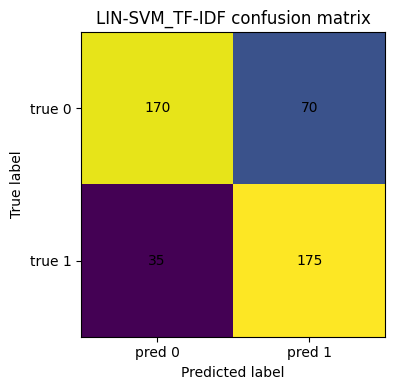

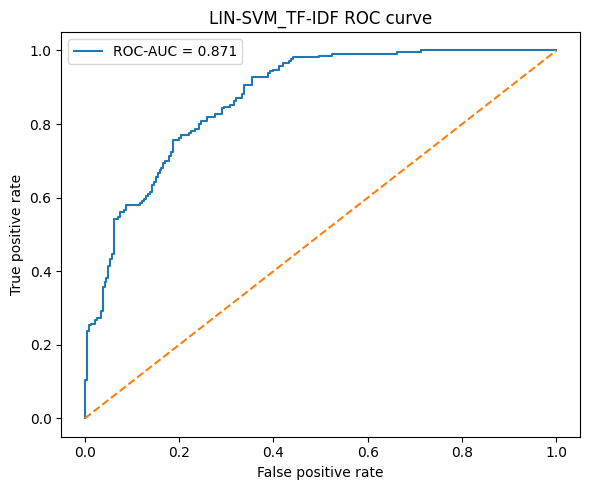

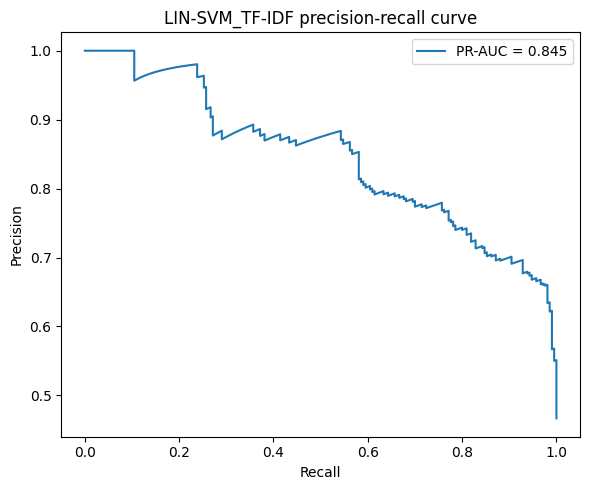

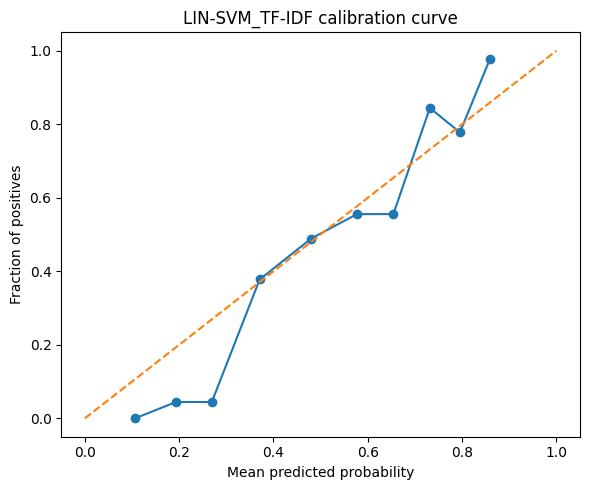

Saved diagnostic plots.


In [15]:
# ============================================================
# 15. Diagnostic plots
# ============================================================

def save_confusion_matrix_plot(cm, path: Path):
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm)
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["pred 0", "pred 1"])
    ax.set_yticklabels(["true 0", "true 1"])
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title(f"{TECHNIQUE_NAME} confusion matrix")

    for r in range(cm.shape[0]):
        for c in range(cm.shape[1]):
            ax.text(c, r, str(cm[r, c]), ha="center", va="center")

    fig.tight_layout()
    fig.savefig(path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)

def save_roc_plot(y_true, y_prob, path: Path):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(fpr, tpr, label=f"ROC-AUC = {safe_roc_auc(y_true, y_prob):.3f}")
    ax.plot([0, 1], [0, 1], linestyle="--")
    ax.set_xlabel("False positive rate")
    ax.set_ylabel("True positive rate")
    ax.set_title(f"{TECHNIQUE_NAME} ROC curve")
    ax.legend()
    fig.tight_layout()
    fig.savefig(path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)

def save_pr_plot(y_true, y_prob, path: Path):
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(recall, precision, label=f"PR-AUC = {safe_pr_auc(y_true, y_prob):.3f}")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title(f"{TECHNIQUE_NAME} precision-recall curve")
    ax.legend()
    fig.tight_layout()
    fig.savefig(path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)

def save_calibration_plot(y_true, y_prob, path: Path):
    try:
        prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=10, strategy="quantile")
        fig, ax = plt.subplots(figsize=(6, 5))
        ax.plot(prob_pred, prob_true, marker="o")
        ax.plot([0, 1], [0, 1], linestyle="--")
        ax.set_xlabel("Mean predicted probability")
        ax.set_ylabel("Fraction of positives")
        ax.set_title(f"{TECHNIQUE_NAME} calibration curve")
        fig.tight_layout()
        fig.savefig(path, dpi=200, bbox_inches="tight")
        plt.show()
        plt.close(fig)
    except Exception as e:
        print("Could not create calibration plot:", e)

save_confusion_matrix_plot(cm, OUTPUT_DIR / "plots" / "confusion_matrix_test.png")
save_roc_plot(y_test_final, test_prob, OUTPUT_DIR / "plots" / "roc_curve_test.png")
save_pr_plot(y_test_final, test_prob, OUTPUT_DIR / "plots" / "pr_curve_test.png")
save_calibration_plot(y_test_final, test_prob, OUTPUT_DIR / "plots" / "calibration_curve_test.png")

print("Saved diagnostic plots.")


In [16]:
# ============================================================
# 16. Global interpretability: Linear SVM margin coefficients and contributions
# ============================================================

coef = explanation_margin_model.coef_.ravel()
intercept = float(explanation_margin_model.intercept_[0])

global_coef_df = pd.DataFrame({
    "feature_name": feature_names,
    "coefficient": coef,
    "abs_coefficient": np.abs(coef),
})

# Positive coefficients push the SVM decision margin toward the extremist class.
top_positive = (
    global_coef_df
    .sort_values("coefficient", ascending=False)
    .head(CONFIG["explainability"]["top_n_global"])
    .reset_index(drop=True)
)

top_negative = (
    global_coef_df
    .sort_values("coefficient", ascending=True)
    .head(CONFIG["explainability"]["top_n_global"])
    .reset_index(drop=True)
)

# Contribution-based importance considers how much features actually appear in test examples.
# contribution = tfidf_value * SVM coefficient
# This explains the LinearSVC decision margin, not the calibrated probability.
test_contrib = X_test_final.multiply(coef)
mean_abs_contrib = np.asarray(np.abs(test_contrib).mean(axis=0)).ravel()

global_contrib_df = pd.DataFrame({
    "feature_name": feature_names,
    "coefficient": coef,
    "mean_abs_test_margin_contribution": mean_abs_contrib,
})
global_contrib_df = global_contrib_df.sort_values(
    "mean_abs_test_margin_contribution",
    ascending=False,
).reset_index(drop=True)

top_positive.to_csv(OUTPUT_DIR / "interpretability" / "top_positive_features_by_margin_coefficient.csv", index=False)
top_negative.to_csv(OUTPUT_DIR / "interpretability" / "top_negative_features_by_margin_coefficient.csv", index=False)
global_contrib_df.head(CONFIG["explainability"]["top_n_global"]).to_csv(
    OUTPUT_DIR / "interpretability" / "top_features_by_mean_abs_test_margin_contribution.csv",
    index=False,
)

global_importance = global_contrib_df.copy()
global_importance["rank_by_mean_abs_margin_contribution"] = np.arange(1, len(global_importance) + 1)
global_importance.to_csv(OUTPUT_DIR / "interpretability" / "global_importance.csv", index=False)

explanation_metadata = {
    "method": "linear_svm_tfidf_margin_contributions",
    "margin_formula": "margin = intercept + sum(tfidf_j * svm_coefficient_j)",
    "local_contribution_formula": "contribution_j = tfidf_value_j * svm_coefficient_j",
    "explained_scale": "LinearSVC decision margin for positive class",
    "probability_note": "The predictive model is calibrated for probabilities. Interpretability uses a separate uncalibrated LinearSVC trained with the same hyperparameters to explain margin-level behavior.",
    "shap_used": False,
    "can_add_shap_later": True,
    "positive_class": "extremist",
    "negative_class": "non_extremist",
    "caveat": "Features are TF-IDF n-grams, not causal explanations or semantic concepts. Margin contributions are not calibrated probability contributions.",
}
save_json(explanation_metadata, OUTPUT_DIR / "interpretability" / "explanation_metadata.json")

print("Top positive features:")
display(top_positive.head(20))

print("\nTop negative features:")
display(top_negative.head(20))

print("\nTop features by mean absolute test margin contribution:")
display(global_contrib_df.head(20))


Top positive features:


,feature_name,coefficient,abs_coefficient
0,kill,2.025171,2.025171
1,shoot,1.250915,1.250915
2,murder,1.208434,1.208434
3,genocide,0.968216,0.968216
4,attack,0.929429,0.929429
5,burn,0.865695,0.865695
6,bomb,0.799357,0.799357
7,white,0.693435,0.693435
8,them,0.678982,0.678982
9,animals,0.625600,0.625600



Top negative features:


,feature_name,coefficient,abs_coefficient
0,bitch,-2.189100,2.189100
1,scum,-1.100996,1.100996
2,cunt,-0.814206,0.814206
3,trump,-0.789431,0.789431
4,back,-0.786744,0.786744
5,home,-0.703425,0.703425
6,ass,-0.587826,0.587826
7,trumpisatraitor,-0.562595,0.562595
8,disgusting,-0.534901,0.534901
9,stupid,-0.532569,0.532569



Top features by mean absolute test margin contribution:


,feature_name,coefficient,mean_abs_test_margin_contribution
0,bitch,-2.189100,0.078377
1,kill,2.025171,0.060092
2,murder,1.208434,0.022922
3,are,0.553877,0.018625
4,scum,-1.100996,0.016976
5,attack,0.929429,0.014715
6,fucking,-0.522573,0.014152
7,all,0.525909,0.012916
8,them,0.678982,0.011775
9,they,0.479906,0.011724


In [17]:
# ============================================================
# 17. Local interpretability for selected test examples
# ============================================================

def get_local_linear_explanation(row_index_in_split, X_matrix, feature_names, coef, top_k=15):
    row = X_matrix[row_index_in_split]
    contrib = row.multiply(coef).tocoo()

    if contrib.nnz == 0:
        return {
            "top_positive_features": [],
            "top_negative_features": [],
        }

    local_df = pd.DataFrame({
        "feature_index": contrib.col,
        "feature_name": feature_names[contrib.col],
        "tfidf_value": np.asarray(row[:, contrib.col].todense()).ravel(),
        "coefficient": coef[contrib.col],
        "margin_contribution": contrib.data,
    })

    top_pos = (
        local_df
        .sort_values("margin_contribution", ascending=False)
        .head(top_k)
        .to_dict(orient="records")
    )

    top_neg = (
        local_df
        .sort_values("margin_contribution", ascending=True)
        .head(top_k)
        .to_dict(orient="records")
    )

    return {
        "top_positive_features": top_pos,
        "top_negative_features": top_neg,
    }

def compact_feature_list(records):
    return [
        {
            "feature": r["feature_name"],
            "tfidf": float(r["tfidf_value"]),
            "coef": float(r["coefficient"]),
            "margin_contribution": float(r["margin_contribution"]),
        }
        for r in records
    ]

def select_examples_for_local_explanations(pred_df, max_total=120):
    selected_parts = []

    fp = pred_df[pred_df["error_type"] == "false_positive"].sort_values("y_prob", ascending=False).head(25)
    selected_parts.append(fp.assign(selection_bucket="high_confidence_false_positive"))

    fn = pred_df[pred_df["error_type"] == "false_negative"].sort_values("y_prob", ascending=True).head(25)
    selected_parts.append(fn.assign(selection_bucket="high_confidence_false_negative"))

    pred_df2 = pred_df.copy()
    pred_df2["distance_to_threshold"] = np.abs(pred_df2["y_prob"] - pred_df2["threshold"])

    near_fp = (
        pred_df2[pred_df2["error_type"] == "false_positive"]
        .sort_values("distance_to_threshold", ascending=True)
        .head(25)
    )
    selected_parts.append(near_fp.assign(selection_bucket="near_threshold_false_positive"))

    near_fn = (
        pred_df2[pred_df2["error_type"] == "false_negative"]
        .sort_values("distance_to_threshold", ascending=True)
        .head(25)
    )
    selected_parts.append(near_fn.assign(selection_bucket="near_threshold_false_negative"))

    tp = pred_df[pred_df["error_type"] == "true_positive"].sort_values("y_prob", ascending=False).head(15)
    tn = pred_df[pred_df["error_type"] == "true_negative"].sort_values("y_prob", ascending=True).head(15)
    selected_parts.append(tp.assign(selection_bucket="high_confidence_true_positive"))
    selected_parts.append(tn.assign(selection_bucket="high_confidence_true_negative"))

    selected = pd.concat(selected_parts, axis=0).drop_duplicates(subset=["row_id"])
    selected = selected.head(max_total).reset_index(drop=True)

    return selected

selected_pred_examples = select_examples_for_local_explanations(
    test_predictions,
    max_total=CONFIG["explainability"]["max_local_examples_total"],
)

test_row_position = {rid: i for i, rid in enumerate(test_df[id_col].tolist())}

local_rows = []
for _, pred_row in selected_pred_examples.iterrows():
    rid = pred_row["row_id"]
    pos = test_row_position[rid]

    explanation = get_local_linear_explanation(
        row_index_in_split=pos,
        X_matrix=X_test_final,
        feature_names=feature_names,
        coef=coef,
        top_k=CONFIG["explainability"]["top_k_local_features"],
    )

    base = {
        "run_id": RUN_ID,
        "technique": TECHNIQUE_NAME,
        "row_id": rid,
        "selection_bucket": pred_row["selection_bucket"],
        "y_true": int(pred_row["y_true"]),
        "y_pred": int(pred_row["y_pred"]),
        "y_prob": float(pred_row["y_prob"]),
        "y_margin": float(pred_row["y_margin"]) if "y_margin" in pred_row else None,
        "threshold": float(pred_row["threshold"]),
        "error_type": pred_row["error_type"],
        "text_hash": pred_row["text_hash"],
        "top_positive_features_json": json.dumps(compact_feature_list(explanation["top_positive_features"])),
        "top_negative_features_json": json.dumps(compact_feature_list(explanation["top_negative_features"])),
    }

    if CONFIG["explainability"]["include_text_preview"]:
        text_value = test_df.iloc[pos][text_col]
        base["text_preview"] = text_value[:CONFIG["explainability"]["text_preview_chars"]]

    local_rows.append(base)

local_explanations = pd.DataFrame(local_rows)
local_explanations.to_csv(
    OUTPUT_DIR / "interpretability" / "local_explanations.csv",
    index=False,
)

print("Saved local explanations:", OUTPUT_DIR / "interpretability" / "local_explanations.csv")
display(local_explanations.head())


Saved local explanations: /kaggle/working/experiments/LIN-SVM_TF-IDF/interpretability/local_explanations.csv


,run_id,technique,row_id,selection_bucket,y_true,y_pred,y_prob,y_margin,threshold,error_type,text_hash,top_positive_features_json,top_negative_features_json
0,LIN-SVM_TF-IDF_20260620_223929,LIN-SVM_TF-IDF,ex_000275,high_confidence_false_positive,0,1,0.842934,0.686968,0.49,false_positive,3ea5d6f19dd99707,"[{""feature"": ""kill"", ""tfidf"": 0.24597802758216858, ""coef"": 2.0251709576541423, ""margin_contribution"": 0.498147557680...","[{""feature"": ""coyotes"", ""tfidf"": 0.6577910780906677, ""coef"": -0.12154693582145408, ""margin_contribution"": -0.0799524..."
1,LIN-SVM_TF-IDF_20260620_223929,LIN-SVM_TF-IDF,ex_000917,high_confidence_false_positive,0,1,0.811181,0.645976,0.49,false_positive,19d2e6c45afc0e56,"[{""feature"": ""muslim"", ""tfidf"": 0.19854645431041718, ""coef"": 0.5616589646862135, ""margin_contribution"": 0.1115153959...","[{""feature"": ""like"", ""tfidf"": 0.13500459492206573, ""coef"": -0.2004467342363469, ""margin_contribution"": -0.0270612301..."
2,LIN-SVM_TF-IDF_20260620_223929,LIN-SVM_TF-IDF,ex_000134,high_confidence_false_positive,0,1,0.808089,0.597531,0.49,false_positive,7d9caa2fdc3a8e45,"[{""feature"": ""murder"", ""tfidf"": 0.2224789708852768, ""coef"": 1.2084335301387352, ""margin_contribution"": 0.26885104816...","[{""feature"": ""gang"", ""tfidf"": 0.40482017397880554, ""coef"": -0.10594924757751707, ""margin_contribution"": -0.042890392..."
3,LIN-SVM_TF-IDF_20260620_223929,LIN-SVM_TF-IDF,ex_000078,high_confidence_false_positive,0,1,0.805655,0.602651,0.49,false_positive,3298579477ab69db,"[{""feature"": ""murder"", ""tfidf"": 0.44051462411880493, ""coef"": 1.2084335301387352, ""margin_contribution"": 0.5323326423...","[{""feature"": ""face"", ""tfidf"": 0.4163569211959839, ""coef"": -0.21442268999782654, ""margin_contribution"": -0.0892763710..."
4,LIN-SVM_TF-IDF_20260620_223929,LIN-SVM_TF-IDF,ex_000079,high_confidence_false_positive,0,1,0.803772,0.616801,0.49,false_positive,cb095916af59ac75,"[{""feature"": ""kill"", ""tfidf"": 0.15190812945365906, ""coef"": 2.0251709576541423, ""margin_contribution"": 0.307639932001...","[{""feature"": ""slut"", ""tfidf"": 0.20601345598697662, ""coef"": -0.14469779649608508, ""margin_contribution"": -0.029809693..."


In [18]:
# ============================================================
# 18. Error-analysis outputs
# ============================================================

error_df = test_predictions.copy()
error_df["abs_distance_to_threshold"] = np.abs(error_df["y_prob"] - error_df["threshold"])

def confidence_bucket(row):
    if row["abs_distance_to_threshold"] <= CONFIG["error_analysis"]["near_threshold_margin"]:
        return "near_threshold"
    if row["y_prob"] >= 0.90 or row["y_prob"] <= 0.10:
        return "high_confidence"
    return "moderate_confidence"

error_df["confidence_bucket"] = error_df.apply(confidence_bucket, axis=1)
error_df["manual_error_category"] = ""
error_df["manual_notes"] = ""

if not local_explanations.empty:
    feature_cols = local_explanations[
        ["row_id", "top_positive_features_json", "top_negative_features_json"]
    ].drop_duplicates("row_id")
    error_df = error_df.merge(feature_cols, on="row_id", how="left")

if CONFIG["error_analysis"]["include_text_preview"]:
    text_lookup = test_df[[id_col, text_col]].copy()
    text_lookup["text_preview"] = text_lookup[text_col].str.slice(0, CONFIG["error_analysis"]["text_preview_chars"])
    error_df = error_df.merge(text_lookup[[id_col, "text_preview"]], left_on="row_id", right_on=id_col, how="left")
    if id_col in error_df.columns and id_col != "row_id":
        error_df = error_df.drop(columns=[id_col])

error_df.to_csv(OUTPUT_DIR / "error_analysis" / "error_analysis_test.csv", index=False)

review_parts = []
n = CONFIG["error_analysis"]["examples_per_bucket"]

review_parts.append(
    error_df[error_df["error_type"] == "false_positive"]
    .sort_values("y_prob", ascending=False)
    .head(n)
    .assign(review_bucket="highest_confidence_false_positive")
)

review_parts.append(
    error_df[error_df["error_type"] == "false_negative"]
    .sort_values("y_prob", ascending=True)
    .head(n)
    .assign(review_bucket="highest_confidence_false_negative")
)

review_parts.append(
    error_df[error_df["error_type"] == "false_positive"]
    .sort_values("abs_distance_to_threshold", ascending=True)
    .head(n)
    .assign(review_bucket="near_threshold_false_positive")
)

review_parts.append(
    error_df[error_df["error_type"] == "false_negative"]
    .sort_values("abs_distance_to_threshold", ascending=True)
    .head(n)
    .assign(review_bucket="near_threshold_false_negative")
)

selected_review_examples = (
    pd.concat(review_parts, axis=0)
    .drop_duplicates(subset=["row_id"])
    .reset_index(drop=True)
)

selected_review_examples.to_csv(
    OUTPUT_DIR / "error_analysis" / "selected_examples_for_review.csv",
    index=False,
)

print("Saved error analysis files:")
print("-", OUTPUT_DIR / "error_analysis" / "error_analysis_test.csv")
print("-", OUTPUT_DIR / "error_analysis" / "selected_examples_for_review.csv")

display(error_df["error_type"].value_counts().to_frame("count"))
display(error_df.groupby(["error_type", "confidence_bucket"]).size().reset_index(name="count"))


Saved error analysis files:
- /kaggle/working/experiments/LIN-SVM_TF-IDF/error_analysis/error_analysis_test.csv
- /kaggle/working/experiments/LIN-SVM_TF-IDF/error_analysis/selected_examples_for_review.csv


,count
error_type,
true_positive,175
true_negative,170
false_positive,70
false_negative,35


,error_type,confidence_bucket,count
0,false_negative,moderate_confidence,27
1,false_negative,near_threshold,8
2,false_positive,moderate_confidence,58
3,false_positive,near_threshold,12
4,true_negative,high_confidence,14
5,true_negative,moderate_confidence,147
6,true_negative,near_threshold,9
7,true_positive,high_confidence,6
8,true_positive,moderate_confidence,159
9,true_positive,near_threshold,10


In [19]:
# ============================================================
# 19. Save experiment metadata and output README
# ============================================================

metadata = {
    "run_id": RUN_ID,
    "technique": TECHNIQUE_NAME,
    "created_at_utc": dt.datetime.utcnow().replace(microsecond=0).isoformat() + "Z",
    "project_name": CONFIG["project_name"],
    "dataset_version": CONFIG["dataset_version"],
    "split_version": CONFIG["split_version"],
    "random_seed": CONFIG["random_seed"],
    "processed_dataset_path": str(processed_dataset_path),
    "processed_dataset_sha256_16": sha256_file(processed_dataset_path),
    "split_assignments_path": str(split_assignments_path),
    "split_assignments_sha256_16": sha256_file(split_assignments_path),
    "dataset_manifest": dataset_manifest,
    "software_environment": {
        "python_version": platform.python_version(),
        "platform": platform.platform(),
        "numpy_version": np.__version__,
        "pandas_version": pd.__version__,
    },
    "sklearn_version": __import__("sklearn").__version__,
    "model_selection": {
        "ablation_split": "validation",
        "primary_selection_metric": "positive_f1",
        "test_set_used_for_selection": False,
    },
    "final_evaluation": {
        "test_split_used_once_after_selection": True,
        "threshold_selected_on": "validation",
    },
    "probability_calibration": {
        "method": CONFIG["calibration"]["method"],
        "cv": model_cfg["calibration_cv"],
        "fit_on": "train split only",
    },
    "outputs": {
        "config": "config.json",
        "best_config": "best_config.json",
        "ablation_results": "ablation/ablation_results.csv",
        "metrics_validation": "metrics_validation.json",
        "metrics_test": "metrics_test.json",
        "predictions_validation": "predictions_validation.csv",
        "predictions_test": "predictions_test.csv",
        "model_artifacts": "model_artifacts/",
        "plots": "plots/",
        "interpretability": "interpretability/",
        "error_analysis": "error_analysis/",
    },
}

save_json(metadata, OUTPUT_DIR / "metadata.json")

readme_text = f"""# {TECHNIQUE_NAME} outputs

This folder contains the standardized outputs for the `{TECHNIQUE_NAME}` experiment.

## Research protocol

- Dataset: `{CONFIG['dataset_version']}`
- Split version: `{CONFIG['split_version']}`
- Model selection: validation-only
- Primary selection metric: validation positive-class F1
- Threshold selection: validation-only
- Final test evaluation: held-out test split only

## Model details

This model is a calibrated LinearSVC using word-level TF-IDF features. LinearSVC does not natively output probabilities, so the notebook uses train-only cross-validated sigmoid calibration through `CalibratedClassifierCV`.

## Key files

- `metrics_test.json`: final held-out test metrics
- `predictions_test.csv`: standardized row-level test predictions
- `ablation/ablation_results.csv`: validation-only tuning results
- `best_config.json`: selected model configuration
- `model_artifacts/`: trained model/vectorizer/feature names/threshold
- `interpretability/`: global and local margin-contribution outputs
- `error_analysis/`: tables for false-positive/false-negative review
"""

with open(OUTPUT_DIR / "README_outputs.md", "w") as f:
    f.write(readme_text)

print("Saved metadata and output README.")
print("Output directory:", OUTPUT_DIR)


Saved metadata and output README.
Output directory: /kaggle/working/experiments/LIN-SVM_TF-IDF


/tmp/ipykernel_23/350771181.py:8: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "created_at_utc": dt.datetime.utcnow().replace(microsecond=0).isoformat() + "Z",


In [20]:
# ============================================================
# 20. Zip outputs for download / Google Drive storage
# ============================================================

zip_base = Path("/kaggle/working") / f"{TECHNIQUE_NAME}_outputs"
zip_path = shutil.make_archive(
    base_name=str(zip_base),
    format="zip",
    root_dir=OUTPUT_DIR,
)

print("Created zip file:")
print(zip_path)

print("\nUpload this zip to Google Drive:")
print(f"Extremism-Classification-Research/01_model_outputs/{TECHNIQUE_NAME}/")


Created zip file:
/kaggle/working/LIN-SVM_TF-IDF_outputs.zip

Upload this zip to Google Drive:
Extremism-Classification-Research/01_model_outputs/LIN-SVM_TF-IDF/
